<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/ClusterTheRoom_COLAB_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cluster the Room — K-Means In-Class Lab
### STUDENT STARTER (TODOs)

Upload the CSV into Colab (**Files panel**) and run cells top-to-bottom.


In [1]:
DATA_PATH = '/content/cluster_the_room_students.csv'
print('DATA_PATH:', DATA_PATH)


DATA_PATH: /content/cluster_the_room_students.csv


In [2]:
import pandas as pd, numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(DATA_PATH)
display(df.head())
print('Shape:', df.shape)
display(df.isna().mean().sort_values(ascending=False).head(10))


,student_id,favorite_music_genre,preferred_learning_style,daily_caffeine_mg,avg_study_hours_per_week,avg_sleep_hours_per_night,participation_score,primary_device,commute_type,commute_minutes,time_of_day_preference
0,1,R&B,Auditory,0.0,3.8,6.4,70,Phone,Drive,46.0,Evening
1,2,Country,NaN,20.0,6.4,8.4,96,Tablet,Drive,29.0,Evening
2,3,K-Pop,Visual,27.0,7.5,5.9,84,Laptop,Public Transit,25.0,Afternoon
3,4,Country,Reading/Writing,117.0,3.5,6.8,77,Phone,Public Transit,37.0,Afternoon
4,5,Rock,Visual,1579.0,7.1,8.1,91,Phone,Drive,41.0,Morning


Shape: (4000, 11)


,0
daily_caffeine_mg,0.05750
preferred_learning_style,0.03725
commute_minutes,0.02425
favorite_music_genre,0.00000
student_id,0.00000
avg_sleep_hours_per_night,0.00000
avg_study_hours_per_week,0.00000
participation_score,0.00000
primary_device,0.00000
commute_type,0.00000


## 1) Clean the data (typos, missing values, outliers)

In [5]:
# Identify the column types
categorical_cols = [
    'favorite_music_genre',
    'preferred_learning_style',
    'primary_device',
    'commute_type',
    'time_of_day_preference'
]

numeric_cols = [
    'daily_caffeine_mg',
    'avg_study_hours_per_week',
    'avg_sleep_hours_per_night',
    'participation_score',
    'commute_minutes'
]

In [6]:
# Check for typos in categorical columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(sorted(df[col].dropna().unique()))


Column: favorite_music_genre
['Afrobeats', 'Classical', 'Country', 'EDM', 'Hip-Hop', 'Jazz', 'K-Pop', 'Metal', 'Pop', 'R&B', 'Rock']

Column: preferred_learning_style
['Auditory', 'Kinesthetic', 'Reading/Writing', 'Unknown', 'Visual']

Column: primary_device
['Desktop', 'Laptop', 'Phone', 'Tablet']

Column: commute_type
['Bike', 'Drive', 'Public Transit', 'Remote', 'Walk']

Column: time_of_day_preference
['Afternoon', 'Evening', 'Morning', 'Night']


In [7]:
# Count how often each category appears
for col in categorical_cols:
    print(f"\nValue counts for: {col}")
    display(df[col].value_counts(dropna=False))


Value counts for: favorite_music_genre


,count
favorite_music_genre,
EDM,473
Pop,463
Hip-Hop,424
Afrobeats,423
Rock,419
K-Pop,357
Jazz,351
R&B,321
Country,305



Value counts for: preferred_learning_style


,count
preferred_learning_style,
Visual,1182
Reading/Writing,1020
Kinesthetic,884
Auditory,765
Unknown,149



Value counts for: primary_device


,count
primary_device,
Laptop,2494
Phone,804
Desktop,381
Tablet,321



Value counts for: commute_type


,count
commute_type,
Drive,1788
Public Transit,879
Remote,580
Walk,488
Bike,265



Value counts for: time_of_day_preference


,count
time_of_day_preference,
Evening,1265
Afternoon,1219
Morning,948
Night,568


In [8]:
# Clean the typos - Now create a mapping dictionary to standardize the labels.
fix_map = {
    'Hip Hop': 'Hip-Hop',
    'RnB': 'R&B',
    'Kpop': 'K-Pop',
    'Afro beats': 'Afrobeats',
    'Reading & Writing': 'Reading/Writing',
    'Kinaesthetic': 'Kinesthetic'
}

for col in ['favorite_music_genre', 'preferred_learning_style']:
    df[col] = df[col].replace(fix_map)

In [35]:
# TODO: justify your cleaning decisions in 2–3 sentences.
fix_map = {
    'Hip Hop':'Hip-Hop','RnB':'R&B','Kpop':'K-Pop','Afro beats':'Afrobeats',
    'Reading & Writing':'Reading/Writing','Kinaesthetic':'Kinesthetic'
}
for col in ['favorite_music_genre','preferred_learning_style']:
    df[col] = df[col].replace(fix_map)

# Missing values + caps (baseline approach)
df['daily_caffeine_mg'] = df['daily_caffeine_mg'].fillna(df['daily_caffeine_mg'].median()).clip(0, 400)
df['commute_minutes'] = df['commute_minutes'].fillna(df['commute_minutes'].median()).clip(0, 120)
df['preferred_learning_style'] = df['preferred_learning_style'].fillna('Unknown')

df[['daily_caffeine_mg','commute_minutes']].describe()


,daily_caffeine_mg,commute_minutes
count,4000.000000,4000.000000
mean,119.900500,28.879000
std,90.085842,17.938041
min,0.000000,0.000000
25%,45.000000,17.000000
50%,105.000000,27.000000
75%,179.000000,38.000000
max,400.000000,120.000000


In [36]:
# Check numeric columns for outliers using summary statistics
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
daily_caffeine_mg,4000.0,119.900500,90.085842,0.0,45.0,105.0,179.0,400.0
avg_study_hours_per_week,4000.0,5.720725,2.212809,0.0,4.3,5.6,7.1,13.9
avg_sleep_hours_per_night,4000.0,6.857875,1.204083,2.5,6.1,6.9,7.7,10.5
participation_score,4000.0,67.425750,14.604839,10.0,58.0,68.0,78.0,100.0
commute_minutes,4000.0,28.879000,17.938041,0.0,17.0,27.0,38.0,120.0


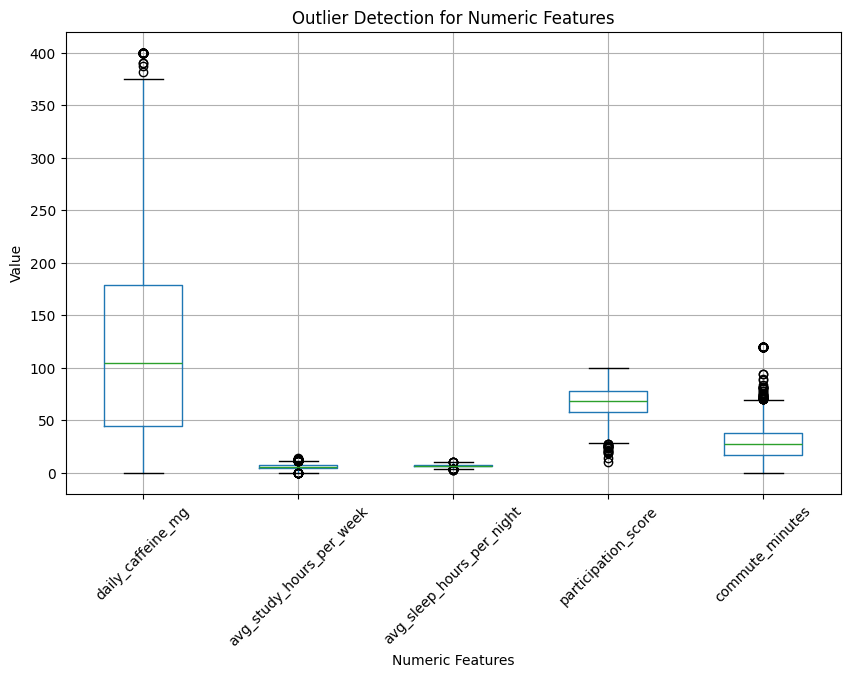

In [37]:
# Visualize outliers with boxplots
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# create boxplot for all numeric columns together
df[numeric_cols].boxplot()

plt.title("Outlier Detection for Numeric Features")
plt.ylabel("Value")
plt.xlabel("Numeric Features")

plt.xticks(rotation=45)

plt.show()

## 2) Preprocess (encode categorical + scale numeric)

In [38]:
# TODO: explain why K-Means is sensitive to feature scaling.
categorical = ['favorite_music_genre','preferred_learning_style','primary_device','commute_type','time_of_day_preference']
numeric = ['daily_caffeine_mg','avg_study_hours_per_week','avg_sleep_hours_per_night','participation_score','commute_minutes']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numeric),
])
X = preprocess.fit_transform(df)
print('X shape:', X.shape)


X shape: (4000, 34)


## 3) Choose k (quick elbow + silhouette on a sample)

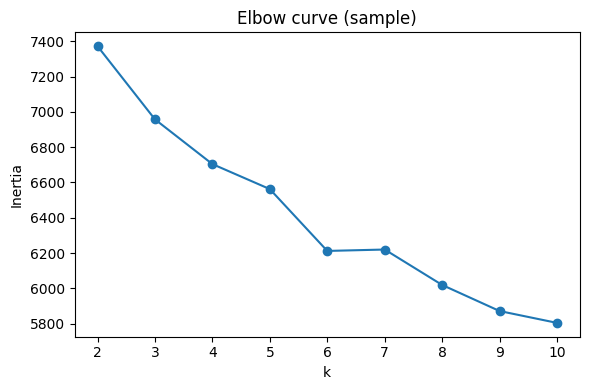

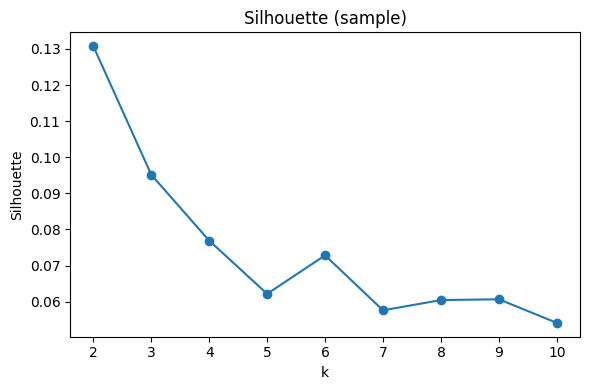

In [39]:
# TODO: choose a final k and justify it using elbow OR silhouette.
sample = df.sample(n=min(1000, len(df)), random_state=42)
Xs = preprocess.fit_transform(sample)

ks = range(2, 11)
inertia = []
sil = []
for k in ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=512, n_init=10)
    labels = km.fit_predict(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, labels))

plt.figure(figsize=(6,4))
plt.plot(list(ks), inertia, marker='o')
plt.title('Elbow curve (sample)')
plt.xlabel('k'); plt.ylabel('Inertia')
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(ks), sil, marker='o')
plt.title('Silhouette (sample)')
plt.xlabel('k'); plt.ylabel('Silhouette')
plt.tight_layout(); plt.show()


## 4) Fit K-Means on full data + interpret clusters

In [45]:
# TODO: write a 1–2 sentence persona for each cluster.
k_final = 6
kmeans = MiniBatchKMeans(n_clusters=k_final, random_state=42, batch_size=512, n_init=10)
labels = kmeans.fit_predict(X)
df['cluster'] = labels

summary = df.groupby('cluster')[numeric].mean().round(2)
display(summary)


,daily_caffeine_mg,avg_study_hours_per_week,avg_sleep_hours_per_night,participation_score,commute_minutes
cluster,,,,,
0,49.02,8.36,7.55,78.46,18.95
1,243.73,4.47,6.13,53.00,23.73
2,87.05,4.02,7.57,70.73,20.28
3,158.98,4.53,5.49,69.34,37.14
4,62.49,6.18,7.65,79.91,45.01
5,100.29,6.74,6.77,56.42,34.31


In [3]:
# The DataFrame 'df' was not found, likely because previous cells were not executed.
# Adding essential setup here to ensure 'df' and 'cluster' column are defined for this cell.

import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import MiniBatchKMeans

DATA_PATH = '/content/cluster_the_room_students.csv'
df = pd.read_csv(DATA_PATH)

# Column definitions from cell mdoxVxRv3Xsc
categorical_cols = [
    'favorite_music_genre', 'preferred_learning_style', 'primary_device',
    'commute_type', 'time_of_day_preference'
]
numeric_cols = [
    'daily_caffeine_mg', 'avg_study_hours_per_week',
    'avg_sleep_hours_per_night', 'participation_score', 'commute_minutes'
]

# Cleaning steps from cells _jIjM4nJ45Mc and 6697f0f7
fix_map = {
    'Hip Hop': 'Hip-Hop', 'RnB': 'R&B', 'Kpop': 'K-Pop',
    'Afro beats': 'Afrobeats', 'Reading & Writing': 'Reading/Writing',
    'Kinaesthetic': 'Kinesthetic'
}
for col in ['favorite_music_genre', 'preferred_learning_style']:
    df[col] = df[col].replace(fix_map)

df['daily_caffeine_mg'] = df['daily_caffeine_mg'].fillna(df['daily_caffeine_mg'].median()).clip(0, 400)
df['commute_minutes'] = df['commute_minutes'].fillna(df['commute_minutes'].median()).clip(0, 120)
df['preferred_learning_style'] = df['preferred_learning_style'].fillna('Unknown')

# Preprocessing from cell cf358b0f
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols),
])
X = preprocess.fit_transform(df)

# K-Means fitting from cell d156cb55
k_final = 6
kmeans = MiniBatchKMeans(n_clusters=k_final, random_state=42, batch_size=512, n_init=10)
labels = kmeans.fit_predict(X)
df['cluster'] = labels

# Original code from this cell
cluster_music_genre = df.groupby('cluster')['favorite_music_genre'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
print("Favorite music genre for each cluster:")
display(cluster_music_genre)

Favorite music genre for each cluster:


,favorite_music_genre
cluster,
0,Jazz
1,EDM
2,Hip-Hop
3,EDM
4,Rock
5,Hip-Hop


## 5) Visualize clusters (PCA)

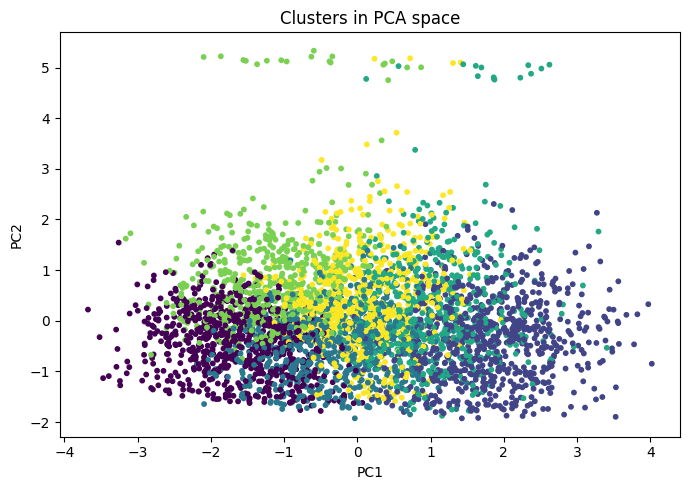

In [46]:
Xd = X.toarray() if hasattr(X, 'toarray') else X
X2 = PCA(n_components=2, random_state=42).fit_transform(Xd)
plt.figure(figsize=(7,5))
plt.scatter(X2[:,0], X2[:,1], c=df['cluster'], s=10)
plt.title('Clusters in PCA space')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()


## Reflection Questions (Group)
1. What key insights were revealed through your evaluation process?
2. Which model or technique provided the best results, and why?
3. What were the main challenges faced during the analysis?
4. How do your findings demonstrate the bias-variance tradeoff?
5. What steps could improve model performance and reliability?
